In [2]:
%reset -f

## Imports

In [3]:
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Literal, get_args
import numpy as np
import random
import tensorflow as tf
from collections import deque

## GPU Konfiguration (MacBook Pro)

In [4]:
# GPU Setup für MacBook Pro (Apple Silicon M1/M2/M3)
# Für Intel Macs: automatische GPU-Erkennung

# Prüfe verfügbare Geräte
print("TensorFlow Version:", tf.__version__)
print("\nVerfügbare Geräte:")
for device in tf.config.list_physical_devices():
    print(f"  - {device.device_type}: {device.name}")

# GPU-Speicher dynamisch wachsen lassen (empfohlen für MacBooks)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n✓ GPU gefunden und konfiguriert: {len(gpus)} GPU(s)")
        print("  Memory Growth aktiviert (dynamische Speicherzuweisung)")
    except RuntimeError as e:
        print(f"GPU Konfigurationsfehler: {e}")
else:
    print("\n⚠ Keine GPU gefunden - Training läuft auf CPU")
    print("\nFür Apple Silicon (M1/M2/M3) MacBooks:")
    print("  Installiere: pip install tensorflow-metal")
    print("\nFür Intel MacBooks:")
    print("  GPU-Beschleunigung erfordert externe GPU oder Cloud-Plattform")

TensorFlow Version: 2.16.1

Verfügbare Geräte:
  - CPU: /physical_device:CPU:0
  - GPU: /physical_device:GPU:0

✓ GPU gefunden und konfiguriert: 1 GPU(s)
  Memory Growth aktiviert (dynamische Speicherzuweisung)


## Configuration Data Classes

In [5]:
@dataclass
class TerrainCosts:
    """Kosten für verschiedene Terrain-Typen"""
    free: float
    river: float
    swamp: float
    mountain: float
    
    def to_dict(self) -> Dict[str, float]:
        """Konvertiert zu Dictionary für Kompatibilität"""
        return {
            'free': self.free,
            'river': self.river,
            'swamp': self.swamp,
            'mountain': self.mountain
        }

@dataclass
class ObstacleConfig:
    """Konfiguration für Hindernisse im Grid"""
    river_positions: List[Tuple[int, int]]
    swamp_positions: List[Tuple[int, int]]
    mountain_positions: List[Tuple[int, int]]
    
    def to_dict(self) -> Dict[str, List[Tuple[int, int]]]:
        """Konvertiert zu Dictionary für GridEnvironment"""
        return {
            "river": self.river_positions,
            "swamp": self.swamp_positions,
            "mountain": self.mountain_positions
        }
    
    def total_count(self) -> int:
        """Gibt die Gesamtanzahl aller Hindernisse zurück"""
        return len(self.river_positions) + len(self.swamp_positions) + len(self.mountain_positions)

@dataclass
class GridConfig:
    """Konfiguration für das Grid Environment"""
    shape: Tuple[int, int]
    start_position: Tuple[int, int]
    goal_position: Tuple[int, int]
    obstacles: ObstacleConfig

@dataclass
class RewardConfig:
    """Reward-Konfiguration"""
    goal_reward: float
    terrain_costs: TerrainCosts

@dataclass
class TrainingConfig:
    """Hyperparameter für DQN Training"""
    episodes: int
    learning_rate: float
    gamma: float
    epsilon_start: float
    epsilon_min: float
    batch_size: int
    max_steps: int
    verbose: bool

## Environment

In [6]:
# Movement types
_MOVETYPES = Literal["up", "down", "left", "right"]

# Obstacle types
_OBSTACLES = Literal["river", "swamp", "mountain"]

# GridEnvironment class (identisch mit gridworld.ipynb)
class GridEnvironment:
    def __init__(self, grid_config: GridConfig):
        """
        Generisches GridEnvironment mit Data Class Konfiguration.
        
        Args:
            grid_config: GridConfig Instanz mit allen Environment-Parametern
        """
        self.shape = grid_config.shape
        self.start_position = grid_config.start_position
        self.goal_position = grid_config.goal_position
        self.obstacles = grid_config.obstacles.to_dict()
        self.state = None
        self.reset()
    
    def reset(self):
        """Setzt den State auf die Startposition zurück."""
        self.state = self.start_position
        return self.state
    
    def give_reward(self, reward_config: RewardConfig):
        """
        Berechnet den Reward für den aktuellen State.
        
        Args:
            reward_config: RewardConfig mit Terrain-Kosten und Goal-Reward
        
        Returns:
            float: Reward-Wert
        """
        # Check for goal
        if self.state == self.goal_position:
            return reward_config.goal_reward
        
        # Get terrain costs dict
        terrain_costs = reward_config.terrain_costs.to_dict()
        
        # Check for obstacles
        for obstacle_type, positions in self.obstacles.items():
            if self.state in positions:
                return terrain_costs.get(obstacle_type, terrain_costs['free'])
        
        # Free field
        return terrain_costs['free']
    
    def is_terminal(self):
        """Prüft ob der aktuelle State ein Terminal-State ist."""
        return self.state == self.goal_position
    
    def step(self, action: _MOVETYPES, reward_config: RewardConfig):
        """
        Führt eine Aktion aus und gibt den nächsten State, Reward und Done-Flag zurück.
        
        Args:
            action: Aktion ("up", "down", "left", "right")
            reward_config: RewardConfig mit Terrain-Kosten und Goal-Reward
        
        Returns:
            tuple: (next_state, reward, done)
        """
        next_state = list(self.state)
        match(action):
            case "up":
                next_state[0] = max(0, self.state[0] - 1)
            case "down":
                next_state[0] = min(self.shape[0] - 1, self.state[0] + 1)
            case "left":
                next_state[1] = max(0, self.state[1] - 1)
            case "right":
                next_state[1] = min(self.shape[1] - 1, self.state[1] + 1)
        
        self.state = tuple(next_state)
        reward = self.give_reward(reward_config)
        done = self.is_terminal()
        
        return self.state, reward, done

## Base Agent Class

In [7]:
# Base Agent class
class Agent:
    def __init__(self, environment: GridEnvironment, actions: list = []):
        self.environment = environment
        self.actions = list(actions)
        self.action_space = len(self.actions)

## Deep Q-Network Agent

Der Deep Q-Network (DQN) Agent nutzt ein neuronales Netzwerk anstelle einer Q-Tabelle.

**Vorteile gegenüber Q-Learning:**
- Skaliert besser bei großen State-Spaces
- Kann Generalisierung zwischen ähnlichen States lernen
- Verwendet Experience Replay für stabileres Training

**Architektur:**
- Input: State als Vektor (z.B. Position als [row, col])
- Hidden Layers: 2 Dense Layers mit 24 Neuronen und ReLU Activation
- Output: Q-Werte für jede mögliche Aktion

In [8]:
class DQNAgent(Agent):
    def __init__(self, environment: GridEnvironment, reward_config: RewardConfig, state_units: int, actions: list = [], 
                 learning_rate: float = 0.1, gamma: float = 0.99, epsilon: float = 1.0, 
                 min_epsilon: float = 0.1, batch_size: int = 32):
        super().__init__(environment, actions)
        
        self.reward_config = reward_config
        self.state_units = state_units
        self.memory = deque(maxlen=2000)

        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.batch_size = batch_size

        self.model = self.build_model()

    def build_model(self):
        """Erstellt das neuronale Netzwerk für Deep Q-Learning"""
        input = tf.keras.layers.Input(shape=(self.state_units,))
        hidden = tf.keras.layers.Dense(24, activation='relu')(input)
        hidden = tf.keras.layers.Dense(24, activation='relu')(hidden)
        output = tf.keras.layers.Dense(self.action_space, activation='linear')(hidden)
        model = tf.keras.models.Model(inputs=input, outputs=output)
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model
    
    def remember(self, state, action, reward, next_state, done):
        """Speichert Erfahrungen im Replay Memory"""
        self.memory.append((state, action, reward, next_state, done))

    def best_action(self, state):
        """Wählt die beste Aktion basierend auf den Q-Werten des Netzwerks"""
        q_values = self.model.predict(self.to_tensor(state), verbose=0)
        return self.actions[np.argmax(q_values[0])]

    def choose_action(self, state):
        """Epsilon-greedy Strategie für Exploration vs. Exploitation"""
        if np.random.rand() < self.epsilon:
            return self.actions[np.random.randint(self.action_space)]
        else:
            return self.best_action(state)
    
    def to_tensor(self, state):
        """Konvertiert State zu Tensor für das Netzwerk"""
        return np.asarray(state)[np.newaxis]

    def replay(self):
        """Experience Replay: Trainiert das Netzwerk mit zufälligen Samples aus dem Memory"""
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)
        states, targets = [], []

        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                next_q_values = self.model.predict(self.to_tensor(next_state), verbose=0)[0]
                target += self.gamma * np.amax(next_q_values)
            q_values = self.model.predict(self.to_tensor(state), verbose=0)[0]
            q_values[self.actions.index(action)] = target

            states.append(state)
            targets.append(q_values)

        self.model.fit(np.array(states), np.array(targets), epochs=1, verbose=0)

    def fit(self, episodes: int = 100, verbose: bool = False):
        """Trainiert den DQN Agent"""
        # Berechne epsilon_decay automatisch basierend auf Episodenanzahl
        epsilon_decay = (self.min_epsilon / self.epsilon) ** (1 / episodes)
        
        print(f"Automatisch berechneter Epsilon Decay: {epsilon_decay:.6f}")
        print(f"Epsilon wird von {self.epsilon} auf {self.min_epsilon} über {episodes} Episoden reduziert.\n")
        
        for episode in range(episodes):
            state = self.environment.reset()
            done = False
            total_reward = 0
            steps = 0
            
            while not done:
                action = self.choose_action(state)
                next_state, reward, done = self.environment.step(action, self.reward_config)
                self.remember(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
                steps += 1
                
            self.replay()
            
            # Epsilon Decay nach jeder Episode
            self.epsilon = max(self.min_epsilon, self.epsilon * epsilon_decay)

            if verbose and episode % 10 == 0:
                print(f"Episode: {episode}, Steps: {steps}, Total Reward: {total_reward:.2f}, Epsilon: {self.epsilon:.4f}")

    def path(self, state=None):
        """Simuliert einen optimalen Pfad zum Ziel"""
        if state is None:
            state = self.environment.reset()
        else:
            self.environment.state = state
        
        states = [state]
        actions = []
        done = False
        max_steps = 100  # Verhindert unendliche Schleifen
        
        while not done and len(states) < max_steps:
            action = self.best_action(state)
            state, reward, done = self.environment.step(action, self.reward_config)
            states.append(state)
            actions.append(action)
            if done:
                break
        
        return states, actions

## Konfiguration und Training

In [ ]:
# Grid Konfiguration
grid_config = GridConfig(
    shape=(5, 5),
    start_position=(4, 0),
    goal_position=(0, 4),
    obstacles=ObstacleConfig(
        river_positions=[(1, 1), (2, 1), (3, 1)],
        swamp_positions=[(1, 3), (2, 3)],
        mountain_positions=[(3, 2)]
    )
)

# Reward Konfiguration
reward_config = RewardConfig(
    goal_reward=100.0,
    terrain_costs=TerrainCosts(
        free=0.1,
        river=1.0,
        swamp=0.5,
        mountain=2.0
    )
)

# Training Konfiguration
training_config = TrainingConfig(
    episodes=50,
    learning_rate=0.001,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    batch_size=256,  # Erhöht von 32 → 256 für bessere GPU-Auslastung
    max_steps=100,
    verbose=True
)

### GPU-Optimierte Konfiguration

Für bessere GPU-Auslastung kannst du folgende Parameter anpassen:
- **Größere Batch Size** (64, 128, 256) → Mehr parallele Berechnungen auf der GPU
- **Tieferes Netzwerk** → Mehr Hidden Layers und Neuronen
- **Größeres Grid** → Komplexeres Problem

Aktuelle Config ist für schnelles Testing optimiert.

In [10]:
# Environment und Agent erstellen
env = GridEnvironment(grid_config)
agent = DQNAgent(
    environment=env,
    reward_config=reward_config,
    state_units=2, 
    actions=get_args(_MOVETYPES),
    learning_rate=training_config.learning_rate,
    gamma=training_config.gamma,
    epsilon=training_config.epsilon_start,
    min_epsilon=training_config.epsilon_min,
    batch_size=training_config.batch_size
)

# Training starten
print("Starte DQN Training...")
agent.fit(episodes=training_config.episodes, verbose=training_config.verbose)
print("Training abgeschlossen!")

2025-12-08 15:21:55.910604: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-12-08 15:21:55.910682: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-12-08 15:21:55.910687: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2025-12-08 15:21:55.911069: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-08 15:21:55.911355: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Starte DQN Training...
Automatisch berechneter Epsilon Decay: 0.912011
Epsilon wird von 1.0 auf 0.01 über 50 Episoden reduziert.



2025-12-08 15:21:56.914630: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Episode: 0, Steps: 123, Total Reward: 153.20, Epsilon: 0.9120
Episode: 10, Steps: 24, Total Reward: 106.80, Epsilon: 0.3631
Episode: 10, Steps: 24, Total Reward: 106.80, Epsilon: 0.3631
Episode: 20, Steps: 290, Total Reward: 132.90, Epsilon: 0.1445
Episode: 20, Steps: 290, Total Reward: 132.90, Epsilon: 0.1445
Episode: 30, Steps: 438, Total Reward: 148.20, Epsilon: 0.0575
Episode: 30, Steps: 438, Total Reward: 148.20, Epsilon: 0.0575
Episode: 40, Steps: 4061, Total Reward: 514.00, Epsilon: 0.0229
Episode: 40, Steps: 4061, Total Reward: 514.00, Epsilon: 0.0229
Training abgeschlossen!
Training abgeschlossen!


## Testen des trainierten Agents

In [11]:
# Test: Optimaler Pfad von Start zum Ziel
states, actions = agent.path()
print(f"\nOptimaler Pfad vom Start {grid_config.start_position} zum Ziel {grid_config.goal_position}:")
print("States:", states)
print("Actions:", actions)
print(f"Anzahl Schritte: {len(actions)}")


Optimaler Pfad vom Start (4, 0) zum Ziel (0, 4):
States: [(4, 0), (3, 0), (2, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
Actions: ['up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up',

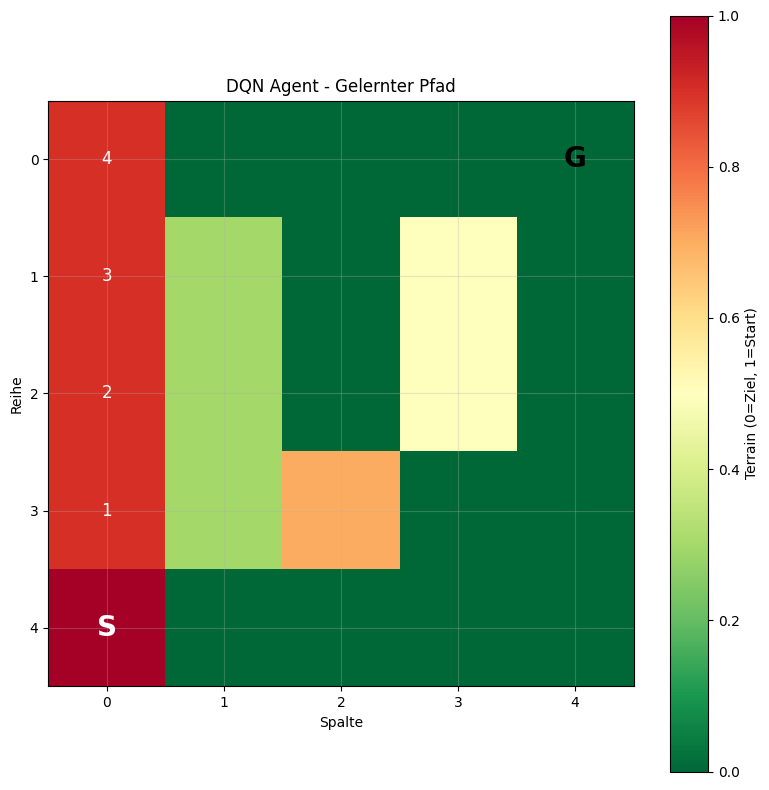

In [12]:
# Visualisierung des Grids mit dem gelernten Pfad
import matplotlib.pyplot as plt

def visualize_path(env, states):
    """Visualisiert das Grid und den Pfad des Agents"""
    grid = np.zeros(env.shape)
    
    # Markiere Hindernisse
    for pos in env.obstacles.get("river", []):
        grid[pos] = 0.3
    for pos in env.obstacles.get("swamp", []):
        grid[pos] = 0.5
    for pos in env.obstacles.get("mountain", []):
        grid[pos] = 0.7
    
    # Markiere Pfad
    for i, state in enumerate(states[:-1]):
        grid[state] = 0.9
    
    # Markiere Start und Ziel
    grid[env.start_position] = 1.0
    grid[env.goal_position] = 0.0
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap='RdYlGn_r', interpolation='nearest')
    plt.colorbar(label='Terrain (0=Ziel, 1=Start)')
    
    # Beschriftungen
    for i in range(env.shape[0]):
        for j in range(env.shape[1]):
            if (i, j) == env.start_position:
                plt.text(j, i, 'S', ha='center', va='center', color='white', fontsize=20, weight='bold')
            elif (i, j) == env.goal_position:
                plt.text(j, i, 'G', ha='center', va='center', color='black', fontsize=20, weight='bold')
            elif (i, j) in states:
                step = states.index((i, j))
                plt.text(j, i, str(step), ha='center', va='center', color='white', fontsize=12)
    
    plt.title('DQN Agent - Gelernter Pfad')
    plt.xlabel('Spalte')
    plt.ylabel('Reihe')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_path(env, states)